# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [7]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "/workspaces/GCAP3226_week4/week4_ae_triage_h1.csv"

path = Path("/workspaces/GCAP3226_week4/week4_ae_triage_h1.csv")
df=pd.read_csv(path)
print("Using:", path.resolve())
df



Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [13]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Write Python code to add pct_change, display the table,
#          print largest fall and largest rise; also 4+5 combined percentage change
# Output: table + printed fall/rise + 4+5 combined
#
# YOUR CODE BELOW

df["pct_change"] = (
    (df["attend_h1_2026"] - df["attend_h1_2025"])
    / df["attend_h1_2025"]
    * 100
)

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]

print("Largest fall:")
print(f"Triage {largest_fall['triage']} ({largest_fall['triage_name']}): {largest_fall['pct_change']:.2f}%")
print("Largest rise:")
print(f"Triage {largest_rise['triage']} ({largest_rise['triage_name']}): {largest_rise['pct_change']:.2f}%")

triage_4_5 = df[df["triage"].isin([4, 5])]
combined_2025 = triage_4_5["attend_h1_2025"].sum()
combined_2026 = triage_4_5["attend_h1_2026"].sum()
combined_pct_change = (combined_2026 - combined_2025) / combined_2025 * 100

print("Triage 4+5 combined:")
print(f"H1 2025: {combined_2025:,}; H1 2026: {combined_2026:,}; percentage change: {combined_pct_change:.2f}%")

df

Largest fall:
Triage 5 (Non-urgent): -20.00%
Largest rise:
Triage 1 (Critical): 5.00%
Triage 4+5 combined:
H1 2025: 507,480; H1 2026: 456,732; percentage change: -10.00%


,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


In [17]:
# Task 1 note
task1_note = """
Triage 1–2 mainly rose, with Critical increasing by about 5.00% and Emergency by about 5.00%, while triage 4–5 mainly fell, with their combined attendances decreasing by 10.00%.
This pattern is consistent with the A&E claim: lower-urgency attendances fell while critical/emergency care was protected.
"""
print(task1_note)



Triage 1–2 mainly rose, with Critical increasing by about 5.00% and Emergency by about 5.00%, while triage 4–5 mainly fell, with their combined attendances decreasing by 10.00%.
This pattern is consistent with the A&E claim: lower-urgency attendances fell while critical/emergency care was protected.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


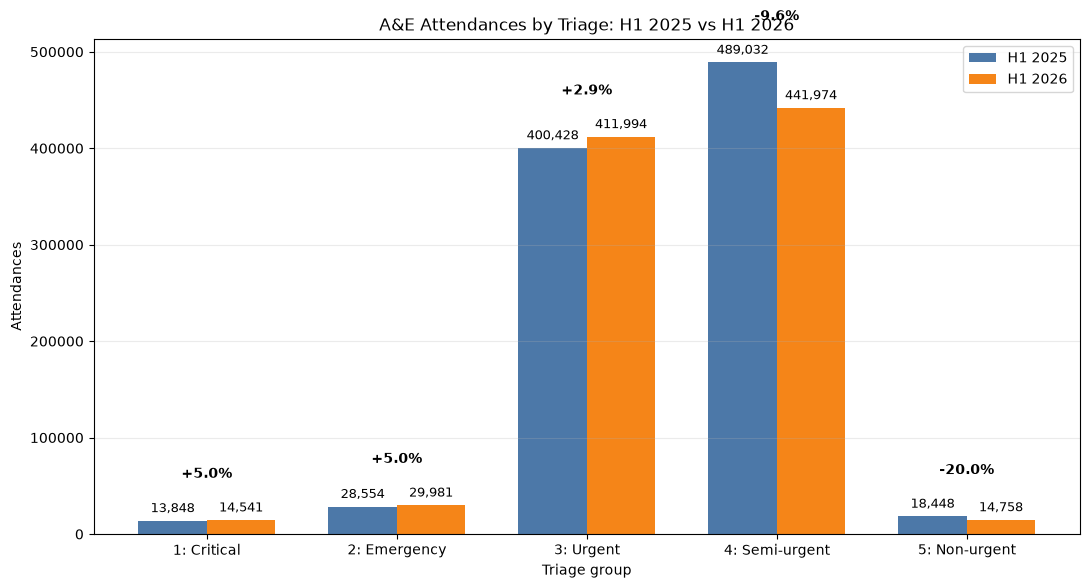

In [19]:
# Task 2 — write your own IPO prompt in the comments, then use Inline Chat
#
# Input:
#   The Task 1 DataFrame, df, with triage labels, H1 2025 attendances,
#   H1 2026 attendances, and pct_change.
#
# Process:
#   Create a grouped bar chart with one H1 2025 bar and one H1 2026 bar
#   for each triage group. Add attendance numbers above every bar and
#   the percentage change above each pair of bars.
#
# Output:
#   A readable chart with 10 bars, a legend, attendance labels, and
#   percentage-change labels for comparing the two periods.
#
# YOUR CODE BELOW

x_positions = list(range(len(df)))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))
bars_2025 = ax.bar(
    [x - bar_width / 2 for x in x_positions],
    df["attend_h1_2025"],
    bar_width,
    label="H1 2025",
    color="#4C78A8",
)
bars_2026 = ax.bar(
    [x + bar_width / 2 for x in x_positions],
    df["attend_h1_2026"],
    bar_width,
    label="H1 2026",
    color="#F58518",
)

for bars in [bars_2025, bars_2026]:
    for bar in bars:
        attendance = int(bar.get_height())
        ax.annotate(
            f"{attendance:,}",
            xy=(bar.get_x() + bar.get_width() / 2, attendance),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

for position, row in zip(x_positions, df.itertuples()):
    pair_height = max(row.attend_h1_2025, row.attend_h1_2026)
    ax.annotate(
        f"{row.pct_change:+.1f}%",
        xy=(position, pair_height),
        xytext=(0, 28),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("A&E Attendances by Triage: H1 2025 vs H1 2026")
ax.set_xlabel("Triage group")
ax.set_ylabel("Attendances")
ax.set_xticks(x_positions)
ax.set_xticklabels(
    [f"{row.triage}: {row.triage_name}" for row in df.itertuples()]
)
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [20]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
Triage 4+5 combined attendances fell by 10.00%, while triage 1 Critical and triage 2 Emergency each rose by about 5.00%. This supports the pattern of lower-urgency demand falling while critical/emergency care remained protected.

3a GAP (1 point):
The comparison covers only two H1 periods and has no control group or other evidence to show that fee reform caused the changes; it also does not by itself measure the full efficiency of urgent care.
"""

task3b = """
3b:
The published evidence provides moderate support for the claim: lower-urgency attendances fell by 10.00% for triage 4+5, while critical and emergency attendances rose by about 5.00% each. The cited triage III result also improved from 81.4% to 88.5% within 30 minutes, and mean wait fell from 23 to 20 minutes. However, the evidence is based on a before-and-after comparison, so it shows an association rather than proving that fee reform caused all of the improvements.
"""

print(task3a)
print("---")
print(task3b)



3a SUPPORT (1 point, cite a number):
Triage 4+5 combined attendances fell by 10.00%, while triage 1 Critical and triage 2 Emergency each rose by about 5.00%. This supports the pattern of lower-urgency demand falling while critical/emergency care remained protected.

3a GAP (1 point):
The comparison covers only two H1 periods and has no control group or other evidence to show that fee reform caused the changes; it also does not by itself measure the full efficiency of urgent care.

---

3b:
The published evidence provides moderate support for the claim: lower-urgency attendances fell by 10.00% for triage 4+5, while critical and emergency attendances rose by about 5.00% each. The cited triage III result also improved from 81.4% to 88.5% within 30 minutes, and mean wait fell from 23 to 20 minutes. However, the evidence is based on a before-and-after comparison, so it shows an association rather than proving that fee reform caused all of the improvements.



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
